In [ ]:
# Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [ ]:
# Funkcje pomocnicze: wykres predykcji modelu, metryki oceny modelu RMSE i MAE)
# Jeśli RMSE jest dużo wyższe niż MAE, oznacza to, że model radzi sobie dobrze przez większość czasu,
# ale "wywala się" na kilku konkretnych dniach (np. przy nagłych krachach giełdowych).
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [ ]:
# Wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [ ]:
# Ustawiamy zbiory trenujące i testowe oraz szukamy brakujących wartości
training_set = dataset[:'2016'].iloc[:, 1:2].values
test_set = dataset['2017':].iloc[:, 1:2].values

#training_set = dataset[:'2016'].iloc[:, 3:4].values
#test_set = dataset['2017':].iloc[:, 3:4].values

#dataset["Close"][:'2016'].plot(figsize=(16,4), legend=True)
#dataset["Close"]['2017':].plot(figsize=(16,4), legend=True)

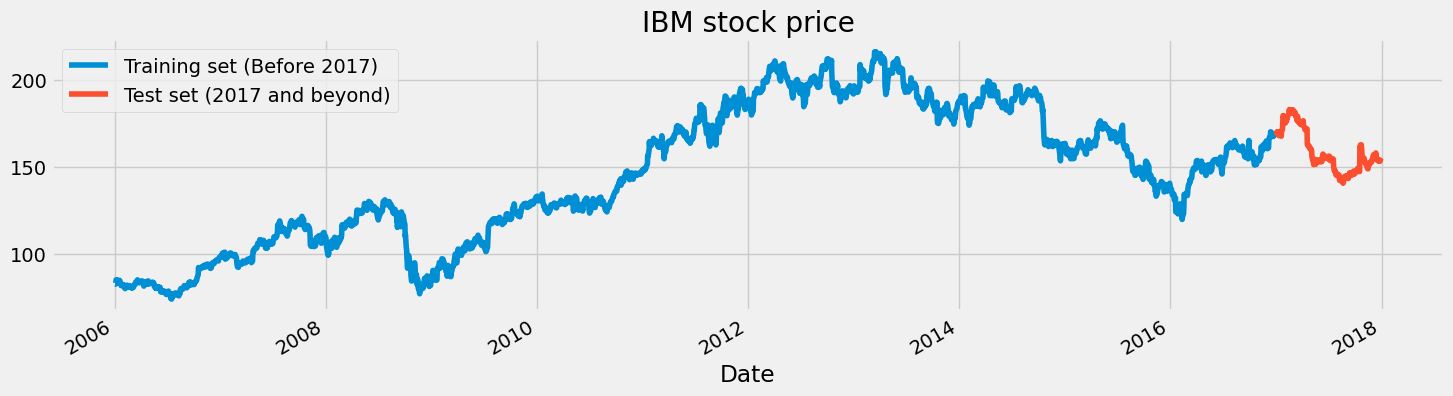

In [ ]:
# Wizualizacja danych
dataset["High"][:'2016'].plot(figsize=(16, 4), legend=True)
dataset["High"]['2017':].plot(figsize=(16, 4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [ ]:
# Normalizacja danych trenujących
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# Ponieważ komórki LSTM przechowują stan pamięci długotrwałej,
# tworzymy strukturę danych z 60 krokami czasowymi i 1 wyjściem
# Zatem dla każdego elementu zestawu treningowego mamy 60 poprzednich elementów zestawu treningowego.
X_train = []
y_train = []
for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Przekształcanie X_train w celu zapewnienia wydajnego modelowania
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
# Blok 9
# Architektura LSTM, sieć regresyjna, predykująca
regressor = Sequential()
# Warstwa wejściowa
regressor.add(Input(shape=(X_train.shape[1], 1)))
# Pierwsza warstwa LSTM
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100))
regressor.add(Dropout(0.2))
# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Ustawimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# MAE
#regressor.compile(optimizer='rmsprop', loss='mean_absolute_error')

#Huber
#regressor.compile(optimizer='rmsprop', loss='Huber')

#Test adam
#regressor.compile(optimizer='adam', loss='mean_squared_error')

#Test SGD
#opt_sgd = SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
#regressor.compile(optimizer=opt_sgd, loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
#regressor.fit(X_train, y_train, epochs=50, batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressor.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0351
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0120
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0084
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0070
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0059
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0051
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0040
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0039
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0033
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

In [ ]:
# Podpinkt E.
# --- OSTATECZNA KONFIGURACJA DLA LSTM (PRZEBICIE BARIERY RMSE < 2.0) ---
from keras.optimizers import Adam

regressor = Sequential()

# Warstwa wejściowa
regressor.add(Input(shape=(X_train.shape[1], 1)))

# 4 Warstwy LSTM o zrównoważonej strukturze jednostek
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.1)) # Zmniejszamy delikatnie dropout, aby sieć nie gubiła dynamiki zmian

regressor.add(LSTM(units=32, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units=32))
regressor.add(Dropout(0.1))

# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Strata Hubera doskonale radzi sobie z nagłymi skokami cen (jak ten przy Time=200)
regressor.compile(optimizer=Adam(learning_rate=0.005), loss='Huber')

# Early stopping monitorujący stratę na zbiorze walidacyjnym
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Trenujemy na maksymalnie 100 epok z wydzieleniem 10% danych na walidację
regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0127 - val_loss: 0.0014
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0020 - val_loss: 6.3067e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0021 - val_loss: 5.7072e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0014 - val_loss: 4.8639e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0014 - val_loss: 5.8395e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0014 - val_loss: 7.3776e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0014 - val_loss: 6.3250e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0011 - val_loss: 3.4024e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012 - val_loss: 7.3032e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0010 - val_loss: 3.5489e-04
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.6179e-04 - val_loss: 3.0236e-04
Epoch 12

In [ ]:
# Teraz przygotujemy zestaw testowy w podobny sposób, jak zestaw treningowy.
# Poniższe czynności zostały wykonane tak,
# aby pierwsze 60 elementów zestawu testowego miało 60 poprzednich wartości
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)

#dataset_total = pd.concat((dataset["Close"][:'2016'], dataset["Close"]['2017':]), axis=0)

inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [ ]:
# Przygotowanie X_testu i predykcja cen akcji
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


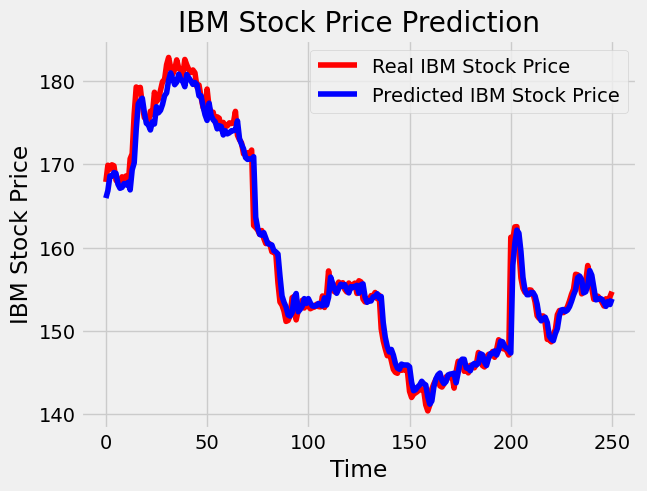

In [ ]:
# Wizualizacja wyników dla sieci LSTM
plot_predictions(test_set, predicted_stock_price)

In [ ]:
# Ocena modelu
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.69.
------------------------------
Średni błąd bezwzględny: 1.06.
Średni błąd bezwzględny procentowy: 0.66%
------------------------------


In [ ]:
# blok 14
# Architektura GRU
regressorGRU = Sequential()
# Pierwsza warstwa GRU z regularyzacją Dropout
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))
regressorGRU.add(GRU(units=50, return_sequences=True))
regressorGRU.add(Dropout(0.2))
# Druga warstwa GRU
regressorGRU.add(GRU(units=50, return_sequences=True))
regressorGRU.add(Dropout(0.2))
# Trzecia warstwa GRU
regressorGRU.add(GRU(units=50, return_sequences=True))
regressorGRU.add(Dropout(0.2))
# Czwarta warstwa GRU
regressorGRU.add(GRU(units=50))
regressorGRU.add(Dropout(0.2))
# Warstwa wyjściowa
regressorGRU.add(Dense(units=1))

# Kompilacja modelu
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True), loss='mean_squared_error')
# Dopasowanie do zestawu treningowego
regressorGRU.fit(X_train, y_train, epochs=50, batch_size=150)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0855
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0285
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0049
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0046
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0043
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0038
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0036
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0035
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0031
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0032
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0030
Epoch 16/50
19/

In [ ]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


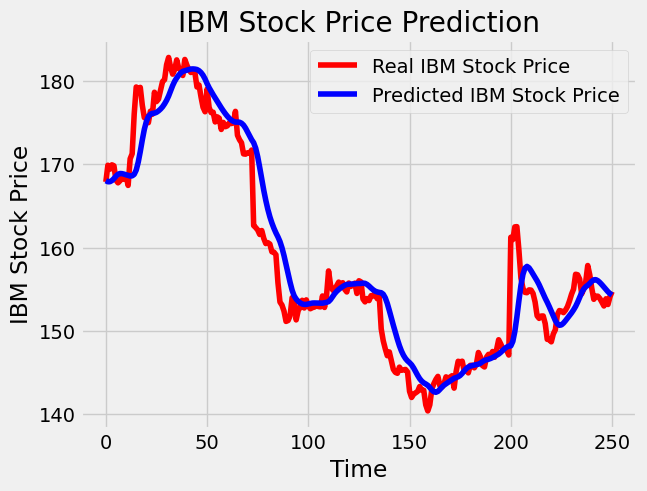

In [ ]:
# Wizualizacja wyników dla sieci GRU
plot_predictions(test_set, GRU_predicted_stock_price)

In [ ]:
# Ocena modelu
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.23.
------------------------------
Średni błąd bezwzględny: 2.20.
Średni błąd bezwzględny procentowy: 1.39%
------------------------------
